# Principal Component Analysis

In [18]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [19]:
# Load dataset
data = load_iris()
X = data.data
y = data.target

In [20]:
# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

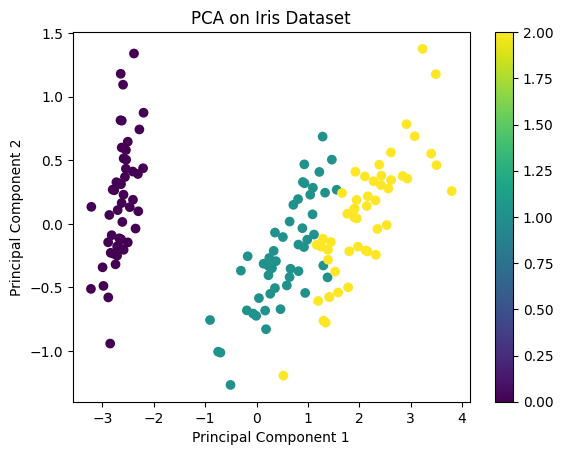

In [21]:
# Plotting
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Iris Dataset')
plt.colorbar()
plt.show()

# 2.breast_cancer_dataset

In [22]:
import pandas as pd                                                                                                                                      
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer

In [23]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
df['target'] = cancer.target

In [24]:
print(df.head(2))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   

   worst smoothness  worst compactness  worst concavity  worst concave points  \
0            0.1622             0.6656           0.7119                0.2654   
1            0.1238             0.1866           0.2416                0.1860   

   worst symmetry  worst fractal dimension  target  
0          0.

In [25]:
print(df.head(2))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   

   worst smoothness  worst compactness  worst concavity  worst concave points  \
0            0.1622             0.6656           0.7119                0.2654   
1            0.1238             0.1866           0.2416                0.1860   

   worst symmetry  worst fractal dimension  target  
0          0.

In [26]:
print(df.shape)

(569, 31)


In [27]:
print(df['target'].value_counts()) 

target
1    357
0    212
Name: count, dtype: int64


In [28]:
x = df.drop('target', axis = 1)
y = df['target']

In [29]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42) 

In [35]:
# Create Pipeline
pipeline = Pipeline([

    # Standardize all features
    # (Mean = 0, Standard Deviation = 1)
    ('scaler', StandardScaler()),

    # Reduce dimensions while keeping 95% variance
    ('pca', PCA(n_components=0.95)),

    # Binary Classification Model
    ('logreg', LogisticRegression(random_state=42))

])


In [36]:
# Train the complete pipeline
# mix (StandardScaler → PCA → Logistic Regression)
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",0.95
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 

In [37]:
y_pred = pipeline.predict(x_test)

In [38]:
print(accuracy_score(y_test, y_pred)) 

0.9824561403508771


# visualization

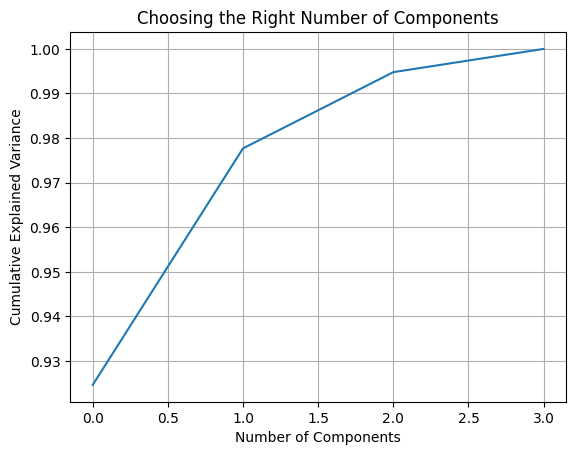

In [5]:
import numpy as np    # Import NumPy library

# Create PCA model and fit it on the dataset
pca = PCA().fit(X)

# Calculate cumulative explained variance
explained = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
plt.plot(explained)

# X-axis label
plt.xlabel("Number of Components")

# Y-axis label
plt.ylabel("Cumulative Explained Variance")

# Graph title
plt.title("Choosing the Right Number of Components")

# Show grid on the graph
plt.grid(True)

# Display the graph
plt.show()

# Choose the minimum number of components
# that explain 95% or more of the total variance.

# without using pipeline

In [15]:
import pandas as pd

# Import Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

# Split dataset into training and testing
from sklearn.model_selection import train_test_split

# Standardize the data
from sklearn.preprocessing import StandardScaler

# Import PCA
from sklearn.decomposition import PCA

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import accuracy function
from sklearn.metrics import accuracy_score


# Load Breast Cancer dataset
cancer = load_breast_cancer()

# Convert dataset into DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add target column
df['target'] = cancer.target

# Count target values
print(df['target'].value_counts())


# Separate input and output
X = df.drop('target', axis=1)
y = df['target']


# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -------------------------------
# Step 1 : Standardization
# -------------------------------

# Create StandardScaler object
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test) #here didn't used fit_transform because already it was learn at the x_train_scaled, so no need to fit_transform for the x_test


# -------------------------------
# Step 2 : PCA
# -------------------------------

# Keep 95% of the variance
pca = PCA(n_components=0.95)

# Apply PCA on training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Apply same PCA on testing data
X_test_pca = pca.transform(X_test_scaled)


# -------------------------------
# Step 3 : Logistic Regression : we used it beacause of target is in binary format
# -------------------------------

# Create Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train_pca, y_train)

# Predict test data
y_pred = model.predict(X_test_pca)


# Calculate accuracy
print("Accuracy :", accuracy_score(y_test, y_pred))

# Print original number of features
print("Original Features :", X_train.shape[1])

# Print features after PCA
print("Features After PCA :", X_train_pca.shape[1])



target
1    357
0    212
Name: count, dtype: int64
Accuracy : 0.9824561403508771
Original Features : 30
Features After PCA : 10
